Epoch 1/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3593 - loss: 1.2636 - val_accuracy: 0.7342 - val_loss: 1.0300
Epoch 2/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7557 - loss: 0.8164 - val_accuracy: 0.8011 - val_loss: 0.6012
Epoch 3/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7857 - loss: 0.5470 - val_accuracy: 0.8046 - val_loss: 0.4395
Epoch 4/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7945 - loss: 0.4595 - val_accuracy: 0.8169 - val_loss: 0.3928
Epoch 5/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8086 - loss: 0.4205 - val_accuracy: 0.8380 - val_loss: 0.3604
Epoch 6/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8250 - loss: 0.3918 - val_accuracy: 0.8592 - val_loss: 0.3365
Epoch 7/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8519 - loss: 0.3674 - val_accuracy: 0.8820 - val_loss: 0.3171
Epoch 8/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8699 - loss: 0.3490 - val_accu

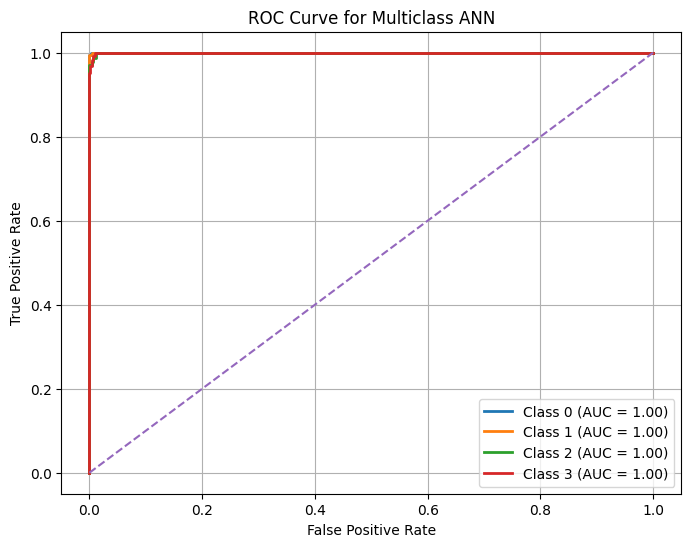

Overall ROC-AUC Score (OvR): 0.9998764848393129
[0.41889986 0.51622003 0.49365303 0.49788434 0.67842031]
Mean accuracy: 0.521015514809591


In [2]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv('final_data.csv')

# Features and target
X = df[['Flow_L_min', 'TDS_smooth', 'Turbidity_smooth']].values
y = df['label'].values

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Number of classes
num_classes = len(np.unique(y))

# Class weights
classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Build improved ANN
model1 = Sequential([
    Input(shape=(3,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile
model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train
history = model1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Evaluate model
loss, accuracy = model1.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predict
predictions = model1.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print("First 10 predicted classes:", predicted_classes[:10])
print("First 10 actual classes:   ", y_test[:10])

# Precision, Recall, F1
precision = precision_score(y_test, predicted_classes, average='weighted')
recall = recall_score(y_test, predicted_classes, average='weighted')
f1 = f1_score(y_test, predicted_classes, average='weighted')

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    predicted_classes,
    target_names=[str(c) for c in le.classes_]
))

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities from model
y_score = model1.predict(X_test)

# Binarize the true labels for multiclass ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass ANN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Overall ROC-AUC score
roc_auc_ovr = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("Overall ROC-AUC Score (OvR):", roc_auc_ovr)


from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(16,8))
scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Mean accuracy:", scores.mean())

In [3]:
total_params = model1.count_params()

print("Total parameters:", total_params)

memory_bytes = total_params * 4
print("Model memory (KB):", memory_bytes / 1024)

Total parameters: 236
Model memory (KB): 0.921875


In [4]:
# Extract weights
weights = model1.get_weights()

for i, w in enumerate(weights):
    print(f"\nLayer {i}:")
    print(w)


Layer 0:
[[-1.0159347   0.21590982  1.186591   -0.6133026  -0.5841333  -0.2990311
  -0.34617367 -0.12088227 -0.79725647 -0.57229674 -0.03247347  0.26894212
  -0.00227266 -1.2148076   1.3049401  -1.1216878 ]
 [-1.4518405  -0.9243546  -0.6139581  -0.37903807  0.0351828   1.2860312
  -1.5325929   0.7488722   0.04143989  0.6413224   1.5098493   0.00566854
  -0.9093101   0.14370058 -0.413438    0.7899436 ]
 [ 0.41587144  0.12443838 -0.47352993 -0.65214515 -0.22559786  0.2987591
   1.0698364  -1.2199538   1.1925511   0.17899811  0.4384604  -1.4133421
  -0.81530064 -0.5525213  -0.08059656 -0.44177675]]

Layer 1:
[ 0.08615877 -0.53124964  0.37312093  0.5330871   0.7991474   0.89572823
 -0.20853306 -0.5277204   0.6821316   0.78868324  0.40253776 -0.3083427
  0.8421675   0.514981    1.028712   -0.3162979 ]

Layer 2:
[[ 0.1657724  -0.24076614  0.40333962  0.25201136  0.7382154  -0.8007982
   0.35983613  0.23257245]
 [-1.6544428   0.33402988  3.426976    1.3160015   0.6986816   0.48584017
  -2.60